#1. Imports


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import os
import matplotlib.pyplot as plt
from PIL import Image # Para abrir las imágenes

#2. Globals



In [ ]:
# Rutas de archivos
DRIVE_ZIP_PATH = '/content/drive/MyDrive/RRDataset_Proyecto/RRDataset_original_train_val.tar.gz'
LOCAL_DATA_PATH = '/content/dataset_extraido'

# Parámetros de entrenamiento
BATCH_SIZE = 32
IMAGE_SIZE = 224  # Tamaño estándar para redes como ResNet o ViT
EPOCHS = 10
LEARNING_RATE = 0.001

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#3. Utils


In [ ]:
def accuracy(outputs, labels):
    """Calcula la precisión para tareas de clasificación."""
    _, preds = torch.max(outputs, 1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

# Aquí podéis añadir funciones para graficar pérdidas más adelante


#4. Data Management


In [ ]:
import os
import tarfile
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# --- 1. CONFIGURACIÓN DE RUTAS ---
ZIP_PATH = '/content/drive/.shortcut-targets-by-id/1auLlAfD-8omSi197ZsTy24Ec3ukakffO/CV Project/RRDataset_test.tar.gz'
DESTINO_LOCAL = '/content/dataset_local'
os.makedirs(DESTINO_LOCAL, exist_ok=True)

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

counts = {}
max_fotos = 300  # <--- Extraemos 300 de cada una (1800 fotos en total) para cumplir con el PDF y tu hardware

print("Extrayendo muestra equilibrada...")

with tarfile.open(ZIP_PATH, 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile() and member.name.lower().endswith(('.png', '.jpg', '.jpeg')):
            path_parts = member.name.split('/')

            clase = 'ai' if 'ai' in path_parts else 'real'
            if 'original' in path_parts: esc = 'original'
            elif 'transfer' in path_parts or 'internet' in path_parts: esc = 'transfer'
            elif 'redigital' in path_parts: esc = 'redigital'
            else: continue

            key = f"{clase}_{esc}"
            if counts.get(key, 0) < max_fotos:
                tar.extract(member, path=DESTINO_LOCAL)
                counts[key] = counts.get(key, 0) + 1

print(f"Extracción completada: {sum(counts.values())} imágenes listas en local.")

# --- 2. DATASET Y SPLIT PROFESIONAL (TRAIN 80% / VAL 20%) ---
class RRDatasetLocal(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    p = os.path.join(root, file)
                    p_parts = p.split('/')
                    c = 1 if 'ai' in p_parts else 0
                    if 'original' in p_parts: t = 0
                    elif 'transfer' in p_parts or 'internet' in p_parts: t = 1
                    else: t = 2
                    self.samples.append((p, c, t))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, c, t = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, c, t

dataset_completo = RRDatasetLocal(DESTINO_LOCAL, transform=data_transforms)
train_size = int(0.8 * len(dataset_completo))
val_size = len(dataset_completo) - train_size

train_dataset, val_dataset = random_split(dataset_completo, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset estructurado: {len(train_dataset)} para entrenar | {len(val_dataset)} para validación pura.")

Extrayendo muestra equilibrada...


/tmp/ipykernel_3109/4100956911.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, path=DESTINO_LOCAL)


Extracción completada: 1800 imágenes listas en local.
Dataset estructurado: 1440 para entrenar | 360 para validación pura.


#5. Network Architecture


In [ ]:
import torchvision.models as models

class MultiTaskModel(nn.Module):
    def __init__(self):
        super(MultiTaskModel, self).__init__()
        # Usamos ResNet18 pre-entrenada como base (el "cuerpo" que reconoce formas)
        self.base_model = models.resnet18(weights='IMAGENET1K_V1')

        # Guardamos el número de características de entrada de la última capa
        num_ftrs = self.base_model.fc.in_features

        # Eliminamos la capa final original de ResNet
        self.base_model.fc = nn.Identity()

        # Creamos las DOS "cabezas" de salida:
        # 1. Cabeza para Clase (Real vs Fake) -> 2 salidas
        self.fc_class = nn.Linear(num_ftrs, 2)

        # 2. Cabeza para Escenario (Original, Transfer, Redigital) -> 3 salidas
        self.fc_trans = nn.Linear(num_ftrs, 3)

    def forward(self, x):
        # La imagen pasa por el cuerpo de la red
        x = self.base_model(x)

        # El resultado se divide en las dos tareas
        out_class = self.fc_class(x)
        out_trans = self.fc_trans(x)

        return out_class, out_trans

# Instanciamos el modelo y lo movemos a la GPU (si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskModel().to(device)

print(f"Modelo configurado y listo en: {device}")

Modelo configurado y listo en: cuda


In [ ]:
# Comprobamos las primeras 5 imágenes y las últimas 5 del dataset
print("--- Primeras muestras ---")
for i in range(5):
    path, l_class, l_trans = full_dataset.samples[i]
    print(f"Foto: {os.path.basename(path)} | Clase (Real=0, IA=1): {l_class} | Escenario: {l_trans}")

print("\n--- Últimas muestras ---")
for i in range(-5, 0):
    path, l_class, l_trans = full_dataset.samples[i]
    print(f"Foto: {os.path.basename(path)} | Clase (Real=0, IA=1): {l_class} | Escenario: {l_trans}")

--- Primeras muestras ---
Foto: Political_&_Social_Events_000145.png | Clase (Real=0, IA=1): 1 | Escenario: 0
Foto: normal_009943.png | Clase (Real=0, IA=1): 1 | Escenario: 0
Foto: Medical_&_Public_Health_000414.png | Clase (Real=0, IA=1): 1 | Escenario: 0
Foto: normal_006080.jpg | Clase (Real=0, IA=1): 1 | Escenario: 0
Foto: Political_&_Social_Events_000606.png | Clase (Real=0, IA=1): 1 | Escenario: 0

--- Últimas muestras ---
Foto: redigital_real_009349.jpg | Clase (Real=0, IA=1): 0 | Escenario: 2
Foto: redigital_real_000046.jpg | Clase (Real=0, IA=1): 0 | Escenario: 2
Foto: redigital_real_006758.jpg | Clase (Real=0, IA=1): 0 | Escenario: 2
Foto: redigital_real_008793.jpg | Clase (Real=0, IA=1): 0 | Escenario: 2
Foto: redigital_real_007864.jpg | Clase (Real=0, IA=1): 0 | Escenario: 2


#6. Training Loop


In [ ]:
import torch
import torch.nn as nn

LAMBDA_CLASS = 0.5
LAMBDA_TRANS = 0.5

criterion_class = nn.CrossEntropyLoss()
criterion_trans = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
EPOCHS = 10

print(f"Iniciando entrenamiento Multi-Task con {len(train_dataset)} muestras...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, labels_class, labels_trans in train_loader:
        images, labels_class, labels_trans = images.to(device), labels_class.to(device), labels_trans.to(device)

        optimizer.zero_grad()
        outputs_class, outputs_trans = model(images)

        loss_class = criterion_class(outputs_class, labels_class)
        loss_trans = criterion_trans(outputs_trans, labels_trans)
        total_loss = (LAMBDA_CLASS * loss_class) + (LAMBDA_TRANS * loss_trans) # Pérdida conjunta del PDF

        total_loss.backward()
        optimizer.step()
        running_train_loss += total_loss.item()

    # Validación en tiempo real (Examen estricto)
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels_class, labels_trans in val_loader:
            images, labels_class, labels_trans = images.to(device), labels_class.to(device), labels_trans.to(device)
            outputs_class, outputs_trans = model(images)

            v_loss_class = criterion_class(outputs_class, labels_class)
            v_loss_trans = criterion_trans(outputs_trans, labels_trans)
            running_val_loss += (LAMBDA_CLASS * v_loss_class) + (LAMBDA_TRANS * v_loss_trans)

    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss Train: {running_train_loss/len(train_loader):.4f} | Loss Val (Fotos nuevas): {running_val_loss/len(val_loader):.4f}")

# Guardado seguro
torch.save(model.state_dict(), '/content/drive/MyDrive/modelo_multitarea_final.pth')
print("Modelo guardado en Drive")

Iniciando entrenamiento Multi-Task con 1440 muestras...
Epoch [1/10] -> Loss Train: 0.7499 | Loss Val (Fotos nuevas): 0.6633
Epoch [2/10] -> Loss Train: 0.3066 | Loss Val (Fotos nuevas): 0.6242
Epoch [3/10] -> Loss Train: 0.1147 | Loss Val (Fotos nuevas): 0.6282
Epoch [4/10] -> Loss Train: 0.0443 | Loss Val (Fotos nuevas): 0.6568
Epoch [5/10] -> Loss Train: 0.0268 | Loss Val (Fotos nuevas): 0.6742
Epoch [6/10] -> Loss Train: 0.0199 | Loss Val (Fotos nuevas): 0.6917
Epoch [7/10] -> Loss Train: 0.0157 | Loss Val (Fotos nuevas): 0.6910
Epoch [8/10] -> Loss Train: 0.0138 | Loss Val (Fotos nuevas): 0.7205
Epoch [9/10] -> Loss Train: 0.0113 | Loss Val (Fotos nuevas): 0.7566
Epoch [10/10] -> Loss Train: 0.0079 | Loss Val (Fotos nuevas): 0.7763
Modelo guardado en Drive


#7. Evaluation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random  # <-- Importamos la librería para generar aleatoriedad

def testear_y_visualizar_aleatorio(model, dataset, n_imagenes=5):
    model.eval()
    fig, axes = plt.subplots(1, n_imagenes, figsize=(22, 6))

    dic_class = {0: "REAL", 1: "IA (FAKE)"}
    dic_trans = {0: "Original", 1: "Internet/Transfer", 2: "Pantalla (Redigital)"}

    # CAMBIO CLAVE: Elegimos 'n_imagenes' (5) índices totalmente al azar sin repetir
    indices = random.sample(range(len(dataset)), n_imagenes)

    for idx, i in enumerate(indices):
        img, label_class, label_trans = dataset[i]

        with torch.no_grad():
            output_class, output_trans = model(img.unsqueeze(0).to(device))

            pred_class = torch.argmax(output_class, dim=1).item()
            pred_trans = torch.argmax(output_trans, dim=1).item()

        # Deshacemos la normalización para pintar la foto bien
        img_display = img.permute(1, 2, 0).cpu().numpy()
        img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img_display = np.clip(img_display, 0, 1)

        axes[idx].imshow(img_display)

        txt_real_class = dic_class[label_class]
        txt_pred_class = dic_class[pred_class]

        txt_real_trans = dic_trans[label_trans]
        txt_pred_trans = dic_trans[pred_trans]

        # Verde si acierta todo, rojo si falla algo
        color_titulo = 'green' if (label_class == pred_class and label_trans == pred_trans) else 'red'

        titulo = f"CLASE:\nReal: {txt_real_class}\nPred: {txt_pred_class}\n\n"
        titulo += f"ESCENARIO:\nReal: {txt_real_trans}\nPred: {txt_pred_trans}"

        axes[idx].set_title(titulo, color=color_titulo, fontsize=10, loc='left')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()



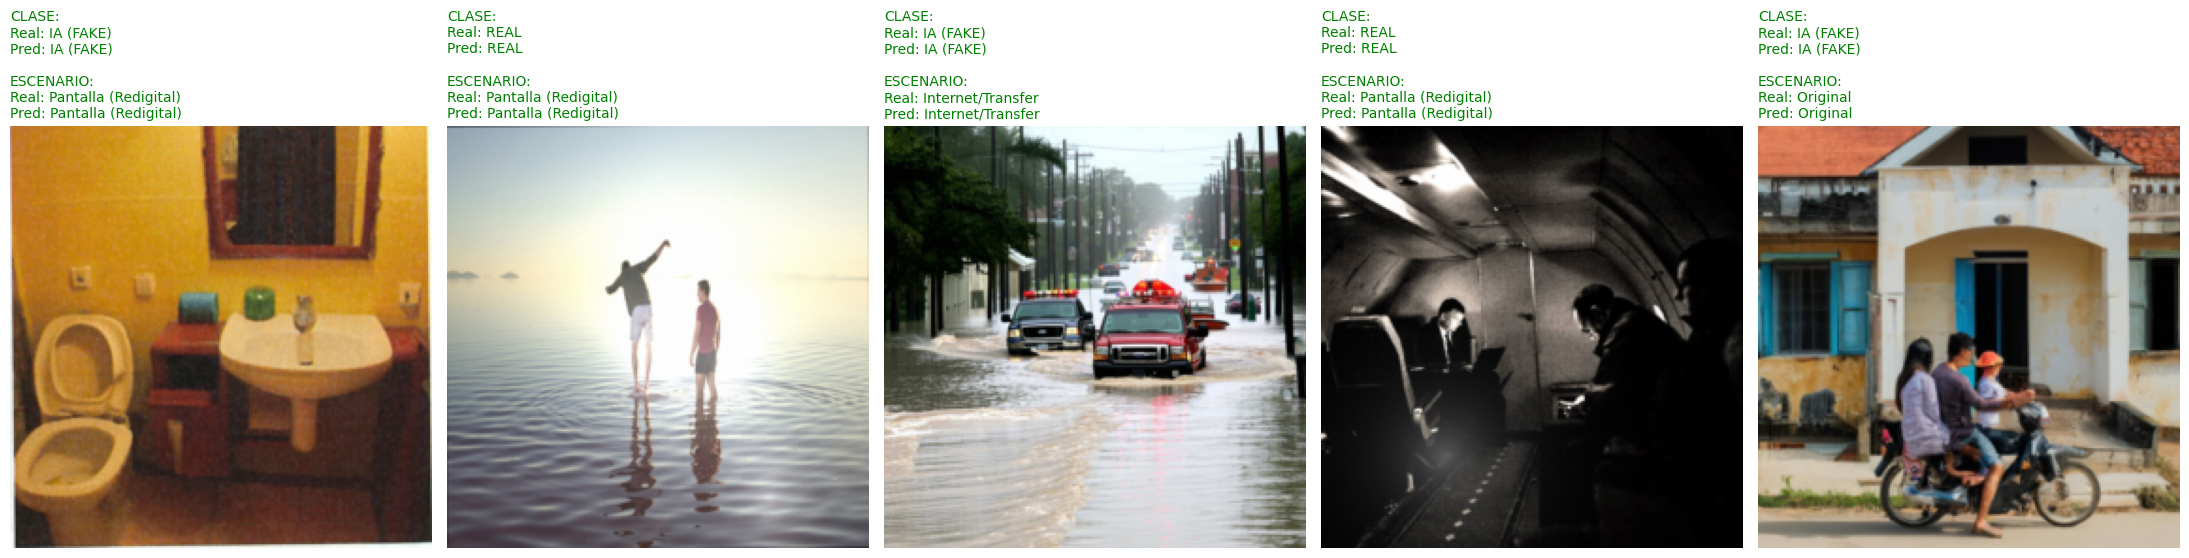

In [ ]:
testear_y_visualizar_aleatorio(model, full_dataset)

#8. Metrics & Analytics

Calculando métricas globales (esto tardará solo unos segundos)...

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

        Real       0.84      0.89      0.86       175
   IA (Fake)       0.89      0.84      0.86       185

    accuracy                           0.86       360
   macro avg       0.86      0.86      0.86       360
weighted avg       0.86      0.86      0.86       360



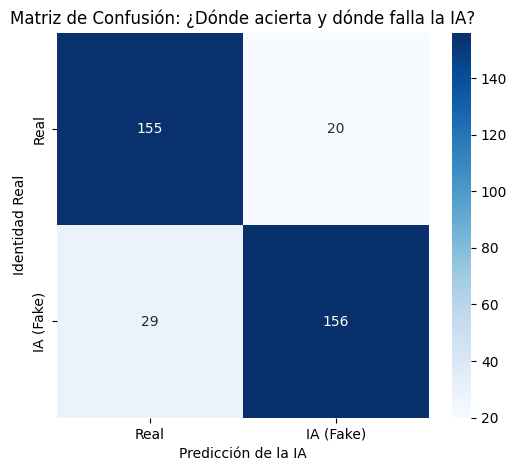

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluar_modelo_completo(model, loader):
    model.eval()
    todas_las_etiquetas = []
    todas_las_predicciones = []

    print("Calculando métricas globales (esto tardará solo unos segundos)...")

    with torch.no_grad():
        for images, labels_class, _ in loader:
            images = images.to(device)

            # Predicción de la IA
            outputs_class, _ = model(images)
            preds = torch.argmax(outputs_class, dim=1)

            # Guardamos los resultados para comparar
            todas_las_etiquetas.extend(labels_class.cpu().numpy())
            todas_las_predicciones.extend(preds.cpu().numpy())

    # 1. Imprimir el reporte de texto (Precisión, Recall, F1-Score)
    print("\nREPORTE DE CLASIFICACIÓN:")
    print(classification_report(todas_las_etiquetas, todas_las_predicciones, target_names=['Real', 'IA (Fake)']))

    # 2. Pintar la Matriz de Confusión Visual
    cm = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'IA (Fake)'], yticklabels=['Real', 'IA (Fake)'])
    plt.xlabel('Predicción de la IA')
    plt.ylabel('Identidad Real')
    plt.title('Matriz de Confusión: ¿Dónde acierta y dónde falla la IA?')
    plt.show()


# Forzamos a que el examen final use las 360 fotos nuevas de validación
evaluar_modelo_completo(model, val_loader)